## ML IDS Project

Started by building a network intrusion detection system that captures raw traffic and pulls out flow level features. Then we trained an XGBoost classifier and set it up to run in real time using a tkinter GUI. Our model can detect six classes: normal, SYN flood, HTTP flood, C2 beaconing, brute force, and SQL injection.

Detection layers:

* To train the XGBoost model, we used 59 features. For example, we included IAT statistics, payload entropy, periodicity, TCP flags, and SQLi patterns.
* We also added the Isolation Forest anomaly score as another feature.
* To help reduce false positives, we set different confidence thresholds for each class.
* We built a temporal engine. For example, alerts only trigger if the same source IP shows up at least three times in a 10 second window.
* We also added hard overrides in cases where there is SQLi payload evidence or when the model is very confident about C2 detections.

For the normal and brute force classes, we used SMOTE. But for C2 and SQLi, we used CTGAN since there were not enough real samples for SMOTE to work.



## Setup

install everything first. thresholds later in the notebook came from trial and error on the validation set, not from theory.(tuned in gui script)

In [ ]:
import os

data_path = r"C:\Users\marya_ewa2aqi\Desktop\DT_project (2)\DT_project\traffic\Dataset"
#replace this with your own path


install packages

In [2]:
import subprocess, sys

packages = [
    "scapy", "tqdm", "xgboost", "imbalanced-learn",
    "scikit-learn", "scipy", "pandas", "numpy",
    "matplotlib", "seaborn", "joblib", "pyshark",
    "cryptography", "ctgan",
]

subprocess.check_call([sys.executable, "-m", "pip", "install"] + packages + ["-q"])
print("done")


done


imports

In [3]:
import os, time, re, gc
from urllib.parse import unquote
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, make_scorer,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from scipy import signal
from tqdm import tqdm
from scapy.all import PcapReader, IP, TCP, UDP, Raw
from ctgan import CTGAN

seed=42
np.random.seed(seed)
print("imports done")


imports done


label map, confidence thresholds per class, resampling targets

C2 and SQLi were the two smallest classes in the captures (~300 and ~450 real flows), so CTGAN made more sense than SMOTE -- SMOTE just interpolated nearly identical flows and the model overfit on those.

In [4]:
print("path = " + data_path)

PCAP={
    name: os.path.join(data_path, name)
    for name in [
        "capture_normal_traffic_final.pcap",
        "http_normal_traffic.pcap",
        "capture_normal_combined.pcap",
        "capture_syn_flood.pcap",
        "capture_http_flood.pcap",
        "capture_command_2_control.pcap",
        "capture_brute_force.pcap",
        "capture_sql_injection_final.pcap",
        "capture_c2_fin.pcap",
        "capture_sql_more.pcap",
    ]
}

COMBI_CSV=os.path.join(data_path, "flows_combined.csv")
model_OUT=os.path.join(data_path, "final_model.pkl")
feats_OUT=os.path.join(data_path, "feature_list.txt")

labelMap={
    0: "Normal",
    1: "SYN_Flood",
    2: "HTTP_Flood",
    3: "Command_Control",
    4: "Brute_Force",
    5: "SQL_Injection",
}

labelMapEx={
    "normal_traffic": 0, "http_normal": 0,  "https_normal": 0,
    "syn_flood": 1,   "http_flood": 2,
    "c2_control": 3,   "c2_final": 3,  "c2_https": 3,
    "brute_force": 4,
    "sql_injection": 5,  "sql_injection_https": 5,
}

C2_THRESH=0.55

confThresh={
    "Normal": None,
    "SYN_Flood":  0.70,
    "HTTP_Flood":  0.50,
    "Command_Control": C2_THRESH,
    "Brute_Force": 0.70,
    "SQL_Injection": 0.82,
}

# sqli and c2 are harder to catch so we weight them higher
costWeights={
    0: 4.0,  1: 1.0,
    2: 2.5,  3: 3.0,
    4: 1.0,  5: 3.0,
}

target_min=50_000
target_flood=70_000
target_sql=45_000

HTTP_PAYLOAD_PORTS={80}

print("configuration done")
print("\nFile availability check:")
for name, path in PCAP.items():
    if os.path.exists(path):
        size="%.1f MB" % (os.path.getsize(path)/1e6); status="OK"
    else:
        size="NOT FOUND"; status="MISSING"
    print(status.ljust(10) + " " + name.ljust(40) + " " + size)


path = C:\Users\marya_ewa2aqi\Desktop\DT_project (2)\DT_project\traffic\Dataset
configuration done

File availability check:
OK         capture_normal_traffic_final.pcap        46.7 MB
OK         http_normal_traffic.pcap                 122.8 MB
OK         capture_normal_combined.pcap             300.4 MB
OK         capture_syn_flood.pcap                   167.7 MB
OK         capture_http_flood.pcap                  114.2 MB
OK         capture_command_2_control.pcap           11.1 MB
OK         capture_brute_force.pcap                 132.3 MB
OK         capture_sql_injection_final.pcap         54.0 MB
OK         capture_c2_fin.pcap                      29.8 MB
OK         capture_sql_more.pcap                    95.2 MB


Detecting periodic C2 beaconing



C2 malware sends traffic back to its server on a fixed timer. In our case, the sample hit port 4444 about every 7 seconds. Normal packet counting did not catch this, so we used a periodogram on the inter-arrival times.



We looked at two features: how strong the main frequency is compared to noise (periodicity_power_ratio), and how many clear peaks show up. Real beacon traffic usually has one or two clean peaks. Background traffic is mostly flat.



In [5]:
# less than 8 iats = FFT garbage ._. dont bother
def periodicity_score(iat_array):
    if len(iat_array) < 8:
        return 0.0, 0
    iats=np.array(iat_array, dtype=float)
    iats=(iats - np.mean(iats)) / (np.std(iats) + 1e-9)
    _, psd=signal.periodogram(iats)
    psd=psd[1:]  # skip DC
    if len(psd) == 0:
        return 0.0, 0
    total_power=np.sum(psd) + 1e-9
    dominant_pwr=np.max(psd)
    num_peaks=int(np.sum(psd > 0.1 * dominant_pwr))
    return float(dominant_pwr / total_power), num_peaks


TLS detection

found that relying only on port 443 is not reliable. for example, the C2 sample we captured was tunneling over port 8443, so it would have been missed. instead, we check the first byte of the TCP payload. if it is 0x16, that means a TLS handshake is happening, no matter which port is used. this also lets us separate encrypted C2 traffic from cleartext brute force attacks on the same port.

In [6]:
def check_tls(flow_packets):
    # 0x16 = TLS handshake content type, works on any port
    for pkt in flow_packets:
        if pkt.haslayer(TCP) and pkt.haslayer(Raw):
            raw=bytes(pkt[Raw].load)
            if len(raw) > 5 and raw[0] == 0x16:
                return {"is_tls": 1}
    return {"is_tls": 0}


SQL injection detection from payloads

Our system decodes HTTP payloads up to 512 bytes to scan for malicious indicators
We encountered a challenge early on where legitimate application traffic on /api/search endpoints triggered false keyword hits because benign user queries often contained common words like 'select' or 'from' as parameters If a benign user searches for a phrase like "How to select a gift from the store," those two keywords appear in the HTTP payload.
To ensure the IDS prioritizes protocol reality over statistical 'hallucinations' on Port 80, we increased the hard-flag threshold to 5 keywords minimum before forcing a SQL Injection label
Furthermore, time-based patterns like sleep() and pg_sleep are tracked as a separate feature; these are highly specific indicators of blind SQL injection and almost never appear in benign traffic, making them reliable triggers even in short payloads.

In [7]:
SQL_KW=[
    "select", "union",  "insert",  "update",
    "delete", "drop",    "exec",    "execute",
    "cast",   "convert", "declare", "xp_",
    "from", "where",  "having",  "order", "group",
]

CLASSIC_PATS=["or 1=1", "or 1=1--", "\' or \'1\'=\'1", "1=1", "or \'x\'=\'x\'"]
TIME_PATS=["waitfor", "sleep(", "benchmark(", "pg_sleep"]

SQLI_KW_THRESH=5  # was 3 but Nessus scanner kept triggering it, bumped up

# check payloads for common injection patterns; this runs on every HTTP flow
def check_sqli(payloads, dst_port=0):
    feats={
        "sql_keyword_count": 0,
        "quote_count": 0,
        "comment_count": 0,
        "classic_injection": 0,
        "hex_encoding_ratio": 0.0,
        "time_based_indicators": 0,
        "sqli_hard_flag": 0,
    }
    if not payloads:
        return feats
    for raw in payloads:
        chunk=raw[:512]
        raw_text=chunk.decode("utf-8", errors="ignore").lower()
        hex_hits=len(re.findall(r"%[0-9a-f]{2}", raw_text))
        feats["hex_encoding_ratio"] += hex_hits / max(len(raw_text), 1)
        text=unquote(raw_text)
        for kw in SQL_KW:
            if kw in text:
                feats["sql_keyword_count"] += 1
        feats["quote_count"] += text.count("'") + text.count('"')
        feats["comment_count"] += text.count("--") + text.count("/*")
        feats["classic_injection"] += int(any(p in text for p in CLASSIC_PATS))
        for p in TIME_PATS:
            if p in text:
                feats["time_based_indicators"] += 1
    if feats["sql_keyword_count"] > SQLI_KW_THRESH:
        feats["sqli_hard_flag"]=1
    return feats

print("Done")


Done


## Feature Extraction from PCAPs


Flow extraction

walk through each PCAP, group packets into bidirectional flows by (src_ip, dst_ip, src_port, dst_port, protocol). for each completed flow compute 58 base features covering timing stats, byte counts, TCP flags, periodicity, entropy, and SQLi indicators. iso anomaly score gets added later.

flows are considered done when idle for 120s, when FIN/RST shows up, or after 6 packets (enough to classify most attacks without waiting forever).

In [8]:
FLOW_TIMEOUT=120   # seconds idle = flow done
MAX_TLS_PKTS=10
MAX_PAYLOADS=20
BATCH_SIZE=50_000

def get_flow_key(pkt):
    if not pkt.haslayer(IP): return None, None
    src, dst=pkt[IP].src, pkt[IP].dst
    proto=pkt[IP].proto
    sport=dport=0
    if TCP in pkt: sport, dport=pkt[TCP].sport, pkt[TCP].dport
    elif UDP in pkt: sport, dport=pkt[UDP].sport, pkt[UDP].dport
    if (src, sport) <= (dst, dport):
        return (src, dst, sport, dport, proto), True
    return (dst, src, dport, sport, proto), False

def empty_flow():
    return {
        "start_ts": None, "last_ts": None, "prev_ts": None,
        "fwd_pkts": 0, "bwd_pkts": 0, "fwd_bytes": 0, "bwd_bytes": 0,
        "fwd_lens": [], "bwd_lens": [],
        "all_iats": [], "fwd_iats": [], "bwd_iats": [],
        "fwd_last_ts": None, "bwd_last_ts": None,
        "fwd_syn": 0, "bwd_syn": 0, "fwd_ack": 0, "bwd_ack": 0,
        "fwd_fin": 0, "bwd_fin": 0, "fwd_rst": 0, "bwd_rst": 0,
        "fwd_psh": 0, "bwd_psh": 0, "fwd_urg": 0, "bwd_urg": 0,
        "http_get": 0, "http_post": 0,
        "payloads": [], "tls_packets": [], "dst_ips": [],
    }

def add_pkt(flow, pkt, is_fwd):
    ts=float(pkt.time)
    plen=len(pkt)
    if flow["start_ts"] is None: flow["start_ts"]=ts
    if flow["prev_ts"] is not None:
        flow["all_iats"].append(ts - flow["prev_ts"])
    flow["prev_ts"]=ts
    flow["last_ts"]=ts
    d="fwd" if is_fwd else "bwd"
    flow[d + "_pkts"] += 1
    flow[d + "_bytes"] += plen
    flow[d + "_lens"].append(plen)
    lk=d + "_last_ts"
    if flow[lk] is not None: flow[d + "_iats"].append(ts - flow[lk])
    flow[lk]=ts
    if TCP in pkt:
        f=int(pkt[TCP].flags)
        for name, mask in [("syn",0x02),("ack",0x10),("fin",0x01),
                           ("rst",0x04),("psh",0x08),("urg",0x20)]:
            if f & mask: flow[d + "_" + name] += 1
        if Raw in pkt and pkt[TCP].dport in HTTP_PAYLOAD_PORTS:
            try:
                raw=bytes(pkt[Raw].load)
                if   raw[:3] == b"GET":  flow["http_get"]  += 1
                elif raw[:4] == b"POST": flow["http_post"] += 1
            except: pass
    flow["dst_ips"].append(pkt[IP].dst)
    if TCP in pkt:
        dp, sp=pkt[TCP].dport, pkt[TCP].sport
        if (dp in HTTP_PAYLOAD_PORTS or sp in HTTP_PAYLOAD_PORTS) and len(flow["payloads"]) < MAX_PAYLOADS:
            if Raw in pkt:
                try: flow["payloads"].append(bytes(pkt[Raw].load)[:512])
                except: pass
        if (dp == 443 or sp == 443) and len(flow["tls_packets"]) < MAX_TLS_PKTS:
            try:
                pb=bytes(pkt[TCP].payload)
                if len(pb) > 5 and pb[0] in (0x16, 0x17): flow["tls_packets"].append(pkt)
            except: pass


# SHANNON ENTROPY GO BRRRRRR
def compute_payload_entropy(payloads):
    if not payloads: return 0.0
    allb=b"".join(payloads)
    if not allb: return 0.0
    counts=np.bincount(np.frombuffer(allb, dtype=np.uint8), minlength=256)
    probs=counts / counts.sum()
    probs=probs[probs > 0]
    return float(-np.sum(probs * np.log2(probs)))


# extract all the features (yes, all of them) :)
def build_features(fid, flow, label):
    def ss(v):
        if not v: return 0.,0.,0.,0.
        a=np.array(v, dtype=float)
        return a.min(), a.max(), a.mean(), a.std()

    dur=(flow["last_ts"] - flow["start_ts"]) if flow["start_ts"] else 0.0
    tp=flow["fwd_pkts"] + flow["bwd_pkts"]
    tb=flow["fwd_bytes"] + flow["bwd_bytes"]
    eps=1e-6

    fl=ss(flow["fwd_lens"])
    bl=ss(flow["bwd_lens"])
    ia=ss(flow["all_iats"])
    fi=ss(flow["fwd_iats"])
    bi=ss(flow["bwd_iats"])

    total_syn=flow["fwd_syn"] + flow["bwd_syn"]
    total_ack=flow["fwd_ack"] + flow["bwd_ack"]
    total_fin=flow["fwd_fin"] + flow["bwd_fin"]
    total_rst=flow["fwd_rst"] + flow["bwd_rst"]

    src, dst, sport, dport, proto=fid
    sqliF=check_sqli(flow["payloads"])
    tlsF=check_tls(flow["tls_packets"])
    entropy=compute_payload_entropy(flow["payloads"])
    pRatio, pPeaks=periodicity_score(flow["all_iats"])

    http_post_ratio=round(flow["http_post"] / (flow["http_get"] + flow["http_post"] + eps), 4)

    return {
        "src_ip": src,    "dst_ip": dst,   "src_port": sport,
        "dst_port": dport, "protocol": proto, "label": label,
        "duration": round(dur, 6),
        "fwd_pkts": flow["fwd_pkts"],   "bwd_pkts": flow["bwd_pkts"],
        "fwd_bytes": flow["fwd_bytes"], "bwd_bytes": flow["bwd_bytes"],
        "total_pkts": tp,  "total_bytes": tb,
        "pkt_rate":  round(tp/(dur+eps), 4),
        "byte_rate": round(tb/(dur+eps), 4),
        "fwd_pkt_len_min": fl[0],  "fwd_pkt_len_max": fl[1],
        "fwd_pkt_len_mean": fl[2], "fwd_pkt_len_std": fl[3],
        "bwd_pkt_len_min": bl[0],  "bwd_pkt_len_max": bl[1],
        "bwd_pkt_len_mean": bl[2], "bwd_pkt_len_std": bl[3],
        "iat_mean": ia[2],  "iat_std": ia[3],
        "iat_min": ia[0],  "iat_max": ia[1],
        "fwd_iat_mean": fi[2], "fwd_iat_std": fi[3],
        "fwd_iat_min": fi[0], "fwd_iat_max": fi[1],
        "bwd_iat_mean": bi[2], "bwd_iat_std": bi[3],
        "bwd_iat_min": bi[0], "bwd_iat_max": bi[1],
        "fwd_syn": flow["fwd_syn"], "bwd_syn": flow["bwd_syn"],
        "fwd_ack": flow["fwd_ack"], "bwd_ack": flow["bwd_ack"],
        "fwd_fin": flow["fwd_fin"], "bwd_fin": flow["bwd_fin"],
        "fwd_rst": flow["fwd_rst"], "bwd_rst": flow["bwd_rst"],
        "fwd_psh": flow["fwd_psh"], "bwd_psh": flow["bwd_psh"],
        "fwd_urg": flow["fwd_urg"], "bwd_urg": flow["bwd_urg"],
        "total_syn": total_syn,  "total_ack": total_ack,
        "total_fin": total_fin,  "total_rst": total_rst,
        "syn_ratio": round(total_syn/(tp+eps), 4),
        "http_get": flow["http_get"],  "http_post": flow["http_post"],
        "http_post_ratio": http_post_ratio,
        "http_get_rate": round(
            (flow["fwd_pkts"] + flow["bwd_pkts"]) / (dur + eps)
            * (1 - (flow["http_post"] / (flow["http_get"] + flow["http_post"] + eps))), 4),
        "unique_dst_ips": len(set(flow["dst_ips"])),
        "payload_entropy": entropy,
        **sqliF,
        **tlsF,
        "periodicity_power_ratio": pRatio,
        "periodicity_num_peaks":   pPeaks,
    }


def extract_flows(pcap_path, label, desc=""):
    active={}
    complete=[]
    batch_dfs=[]

    def _flush():
        nonlocal complete, batch_dfs
        if complete:
            batch_dfs.append(pd.DataFrame(complete))
            complete=[]
            gc.collect()

    with PcapReader(pcap_path) as reader:
        for pkt in tqdm(reader, desc="[" + desc + "]", unit="pkt", leave=False, disable=True):
            if IP not in pkt: continue
            key, is_fwd=get_flow_key(pkt)
            if key is None: continue
            ts=float(pkt.time)
            if key in active and ts - active[key]["last_ts"] > FLOW_TIMEOUT:
                complete.append(build_features(key, active.pop(key), label))
            if key not in active:
                active[key]=empty_flow()
            add_pkt(active[key], pkt, is_fwd)
            if TCP in pkt and (int(pkt[TCP].flags) & (0x01 | 0x04)):
                complete.append(build_features(key, active.pop(key), label))
            if len(complete) >= BATCH_SIZE:
                _flush()

    for key, flow in active.items():
        complete.append(build_features(key, flow, label))
    _flush()

    return pd.concat(batch_dfs, ignore_index=True) if batch_dfs else pd.DataFrame()

print("flow extraction functions ready")


flow extraction functions ready


In [9]:
# build or load the combined dataset

if os.path.exists(COMBI_CSV):
    print("Loading CSV: " + COMBI_CSV)
    df_combined=pd.concat(
        pd.read_csv(COMBI_CSV, chunksize=100_000),
        ignore_index=True,
    )
else:
    print("Extracting flows from PCAPs")

    pcap_to_label={
        "http_normal_traffic.pcap": 0,
        "capture_normal_traffic_final.pcap": 0,
        "capture_normal_combined.pcap": 0,
        "capture_syn_flood.pcap": 1,
        "capture_http_flood.pcap": 2,
        "capture_command_2_control.pcap": 3,
        "capture_brute_force.pcap": 4,
        "capture_sql_injection_final.pcap": 5,
        "capture_c2_fin.pcap": 3,
        "capture_sql_more.pcap": 5,
    }

    dfs=[]

    for key, label in pcap_to_label.items():
        path=PCAP[key]
        if os.path.exists(path):
            dfs.append(extract_flows(path, label, desc=key))
        else:
            print("WARNING: " + key + " not found, skipping")

    df_combined=pd.concat(dfs, ignore_index=True)
    df_combined["binary_label"]=(df_combined["label"] > 0).astype(int)
    df_combined.to_csv(COMBI_CSV, index=False)
    print("Saved to " + COMBI_CSV)

# binary label for any later use
if "binary_label" not in df_combined.columns:
    df_combined["binary_label"]=(df_combined["label"] > 0).astype(int)

# downcast to float32 for memory efficiency
for col in df_combined.select_dtypes(include="float64").columns:
    df_combined[col]=df_combined[col].astype("float32")

gc.collect()

# downcast ints too (except labels)
for col in df_combined.columns:
    if df_combined[col].dtype == "int64" and col not in ["label", "binary_label"]:
        df_combined[col]=df_combined[col].astype("int32")

# show distribution
print("\nClass distribution:")
dist=df_combined["label"].value_counts().sort_index()

for lbl, cnt in dist.items():
    pct=100 * cnt / len(df_combined)
    print(labelMap[lbl].ljust(20) + " " + str(cnt).rjust(8) + "  (" + ("%.1f" % pct) + "%)")

print("TOTAL".ljust(20) + " " + str(len(df_combined)).rjust(8))


Loading CSV: C:\Users\marya_ewa2aqi\Desktop\DT_project (2)\DT_project\traffic\Dataset\flows_combined.csv

Class distribution:
Normal                  49539  (4.7%)
SYN_Flood              609132  (58.2%)
HTTP_Flood             214117  (20.5%)
Command_Control         27741  (2.7%)
Brute_Force             47311  (4.5%)
SQL_Injection           98630  (9.4%)
TOTAL                 1046470


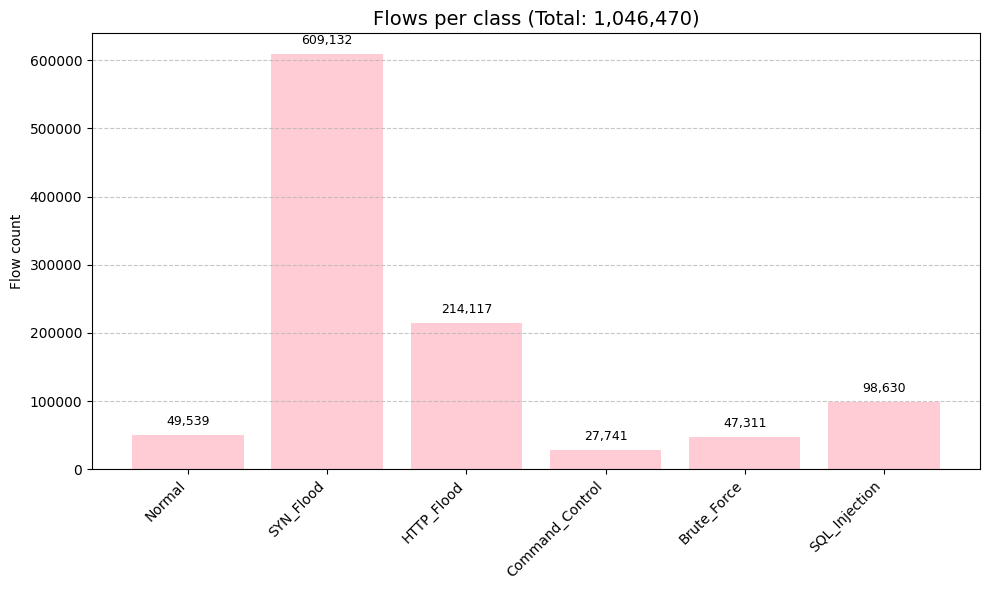

In [10]:
# visualize raw class distribution

class_counts=df_combined['label'].value_counts().sort_index()
class_names=[labelMap[i] for i in class_counts.index]
total_flows=class_counts.sum()

plt.figure(figsize=(10, 6))

bars=plt.bar(class_names, class_counts.values, color='pink', alpha=0.8)

plt.title('Flows per class (Total: ' + "{:,}".format(total_flows) + ')', fontsize=14)
plt.ylabel('Flow count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    height=bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.01 * total_flows,
        "{:,}".format(int(height)),
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(os.path.join(data_path, "class_flows.png"), dpi=150)
plt.show()


In [11]:
# coefficient of variation for IAT and packet length

eps=1e-6

df_combined["fwd_iat_cv"]=df_combined["fwd_iat_std"] / (df_combined["fwd_iat_mean"] + eps)
df_combined["bwd_iat_cv"]=df_combined["bwd_iat_std"] / (df_combined["bwd_iat_mean"] + eps)
df_combined["fwd_len_cv"]=df_combined["fwd_pkt_len_std"] / (df_combined["fwd_pkt_len_mean"] + eps)
df_combined["bwd_len_cv"]=df_combined["bwd_pkt_len_std"] / (df_combined["bwd_pkt_len_mean"] + eps)
df_combined["iat_cv"]=df_combined["iat_std"] / (df_combined["iat_mean"] + eps)

print("CV features added. Total columns: " + str(len(df_combined.columns)))


CV features added. Total columns: 74


## Preprocessing and Resampling


In [12]:
# sanity check -- making sure sqli features actually captured something

print("SQLi flows - hex_encoding_ratio:")
print(df_combined[df_combined["label"] == 5]["hex_encoding_ratio"].describe())

print("\nSQLi flows - sql_keyword_count:")
print(df_combined[df_combined["label"] == 5]["sql_keyword_count"].describe())


SQLi flows - hex_encoding_ratio:
count    98630.000000
mean         0.041385
std          0.087104
min          0.000000
25%          0.000000
50%          0.000000
75%          0.040598
max          0.597656
Name: hex_encoding_ratio, dtype: float64

SQLi flows - sql_keyword_count:
count    98630.000000
mean         0.381426
std          1.189967
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         10.000000
Name: sql_keyword_count, dtype: float64


In [13]:
df=df_combined.copy()

# one hot encode protocol so SMOTE doesn't interpolate values in between like 6.5
df=pd.get_dummies(df, columns=["protocol"], prefix="proto", drop_first=False)

ids_cols=["src_ip", "src_port", "dst_ip", "protocol", "binary_label"]
label_col="label"
feature_cols=[c for c in df.columns if c not in ids_cols + [label_col]]

X=df[feature_cols].copy()
y=df[label_col].copy()

print("Features before cleaning: " + str(len(feature_cols)))

# 80/20 split
X.replace([np.inf, -np.inf], np.nan, inplace=True)

X_train, X_test, y_train, y_test=train_test_split(
    X, y,
    test_size=0.20,
    random_state=seed,
    stratify=y,
)

print("Train: " + "{:,}".format(len(X_train)) + " flows | Test: " + "{:,}".format(len(X_test)) + " flows")

# impute missing values using train median (fit on train only)
train_median=X_train.median(numeric_only=True)
X_train=X_train.fillna(train_median)
X_test=X_test.fillna(train_median)

# drop constant columns
constant=[c for c in X_train.columns if X_train[c].nunique() <= 1]

if constant:
    print("Dropping " + str(len(constant)) + " constant columns")
    X_train.drop(columns=constant, inplace=True)
    X_test.drop(columns=constant, inplace=True)

# drop near zero variance
vt=VarianceThreshold(threshold=1e-8)
vt.fit(X_train)

low_var=[c for c, keep in zip(X_train.columns, vt.get_support()) if not keep]

if low_var:
    print("Dropping " + str(len(low_var)) + " near-zero-var columns")
    X_train.drop(columns=low_var, inplace=True)
    X_test.drop(columns=low_var, inplace=True)

# drop highly correlated columns (> 0.97)
corr=X_train.corr(numeric_only=True).abs()
upper=corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr=[col for col in upper.columns if any(upper[col] > 0.97)]

if high_corr:
    print("Dropping " + str(len(high_corr)) + " highly correlated columns")
    X_train.drop(columns=high_corr, inplace=True)
    X_test.drop(columns=high_corr, inplace=True)

f_list=list(X_train.columns)
print("Features after cleaning: " + str(len(f_list)))

# find sqli hard flag index for later
if "sqli_hard_flag" in f_list:
    sql_idx=f_list.index("sqli_hard_flag")
else:
    sql_idx=None

# robust scaling
scaler=RobustScaler()
X_train_scaled=scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled=scaler.transform(X_test).astype(np.float32)

# isolation forest for anomaly detection trained on normal traffic only
do_iso=True

if do_iso:
    iso_forest=IsolationForest(
        n_estimators=200,
        contamination=0.01,
        random_state=seed,
        n_jobs=-1,
    )

    iso_forest.fit(X_train_scaled[y_train == 0])

    iso_train=iso_forest.decision_function(X_train_scaled).reshape(-1, 1)
    iso_test=iso_forest.decision_function(X_test_scaled).reshape(-1, 1)

    X_train_aug=np.hstack([X_train_scaled, iso_train]).astype(np.float32)
    X_test_aug=np.hstack([X_test_scaled, iso_test]).astype(np.float32)

    aug_feats=f_list + ["iso_anomaly_score"]

    print("IsoForest added. Train shape: " + str(X_train_aug.shape))
else:
    iso_forest=None
    X_train_aug=X_train_scaled
    X_test_aug=X_test_scaled
    aug_feats=list(f_list)

# split train into experiment pool and validation
X_exp_aug, X_val_aug, y_exp_train, y_val=train_test_split(
    X_train_aug,
    y_train,
    test_size=0.15,
    random_state=seed,
    stratify=y_train,
)

print("Experiment pool: " + "{:,}".format(len(X_exp_aug)) + " flows | Val set: " + "{:,}".format(len(X_val_aug)) + " flows")


Features before cleaning: 72
Train: 837,176 flows | Test: 209,294 flows
Dropping 2 constant columns
Dropping 12 highly correlated columns
Features after cleaning: 58
IsoForest added. Train shape: (837176, 59)
Experiment pool: 711,599 flows | Val set: 125,577 flows


In [14]:
# resampling: CTGAN for C2/SQLi , SMOTE for Normal/Brute_Force, undersampling for floods

n_base=len(f_list)

# only base features (no iso score)
X_exp_no_iso=X_exp_aug[:, :n_base]

exp_counts=pd.Series(y_exp_train).value_counts().to_dict()

print("Before resampling:")
print("-" * 30)

for lbl, cnt in sorted(exp_counts.items()):
    print(labelMap[lbl].ljust(20) + " " + str(cnt).rjust(8))

# oversample normal and brute force to target
smote_over={}

for c, tgt in [(0, target_min), (4, target_min)]:
    if exp_counts.get(c, 0) < tgt:
        smote_over[c]=tgt

# undersample floods to target
under_targets={c: target_flood for c in [1, 2] if exp_counts.get(c, 0) > target_flood}

X_resampled=X_exp_no_iso.copy()
y_resampled=y_exp_train.copy()

if smote_over:
    sm_min=min(min(exp_counts.values()) - 1, 5)
    sm=SMOTE(
        sampling_strategy=smote_over,
        random_state=seed,
        k_neighbors=sm_min,
    )
    X_resampled, y_resampled=sm.fit_resample(X_resampled, y_resampled)

if under_targets:
    rus=RandomUnderSampler(
        sampling_strategy=under_targets,
        random_state=seed,
    )
    X_resampled, y_resampled=rus.fit_resample(X_resampled, y_resampled)

# CTGAN for C2 and SQLi (harder patterns)
for cls, target in [(3, target_min), (5, target_sql)]:
    current=(y_resampled == cls).sum()

    if current < target:
        needed=target - current

        data=pd.DataFrame(
            X_exp_no_iso[y_exp_train == cls],
            columns=f_list,
        )

        # tell CTGAN which columns are categorical
        discrete_cols=[
            c for c in f_list if (
                'flag' in c
                or 'proto_' in c
                or 'http_' in c
                or c in ['is_tls', 'sqli_hard_flag', 'classic_injection']
            )
        ]

        ctgan=CTGAN(epochs=300, verbose=False)
        ctgan.fit(data, discrete_columns=discrete_cols)

        synthetic=ctgan.sample(needed)

        X_resampled=np.vstack([X_resampled, synthetic.values])
        y_resampled=np.concatenate([y_resampled, np.full(needed, cls)])

# add iso anomaly score if enabled
if do_iso and iso_forest is not None:
    iso_resampled=iso_forest.decision_function(X_resampled).reshape(-1, 1)
    X_train_smote=np.hstack([X_resampled, iso_resampled]).astype(np.float32)
else:
    X_train_smote=X_resampled.astype(np.float32)

y_train_smote=y_resampled

print("\nAfter resampling:")
print("-" * 30)

final_dist=pd.Series(y_train_smote).value_counts().sort_index()

for lbl, cnt in final_dist.items():
    print("  " + labelMap[lbl].ljust(20) + " " + str(cnt).rjust(8))

print("TOTAL".ljust(20) + " " + str(len(y_train_smote)).rjust(8))

# ensure everything is float32
X_train_scaled=X_train_scaled.astype(np.float32)
X_test_scaled=X_test_scaled.astype(np.float32)
X_train_aug=X_train_aug.astype(np.float32)
X_test_aug=X_test_aug.astype(np.float32)
X_exp_aug=X_exp_aug.astype(np.float32)
X_val_aug=X_val_aug.astype(np.float32)

# save all preprocessing artifacts
prep_data={
    "X_train_smote": X_train_smote,
    "y_train_smote": y_train_smote,
    "X_train_aug": X_train_aug,
    "y_train": y_train,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled,
    "y_test": y_test,
    "X_val_aug": X_val_aug,
    "y_val": y_val,
    "X_exp_aug": X_exp_aug,
    "y_exp_train": y_exp_train,
    "X_test": X_test,
    "scaler": scaler,
    "final_features": f_list,
    "final_features_aug": aug_feats,
    "label_map": labelMap,
    "iso_forest": iso_forest if do_iso else None,
    "use_iso_forest": do_iso,
}

joblib.dump(
    prep_data,
    os.path.join(data_path, "preprocessed_data.pkl"),
    compress=3,
)

print("Saved preprocessed_data.pkl")


Before resampling:
------------------------------
Normal                  33686
SYN_Flood              414209
HTTP_Flood             145600
Command_Control         18864
Brute_Force             32172
SQL_Injection           67068

After resampling:
------------------------------
  Normal                  50000
  SYN_Flood               70000
  HTTP_Flood              70000
  Command_Control         50000
  Brute_Force             50000
  SQL_Injection           67068
TOTAL                  357068
Saved preprocessed_data.pkl


In [15]:
# print final feature list

print("Total features: " + str(len(aug_feats)))
print("-" * 40)

for i, feature in enumerate(aug_feats, 1):
    print(str(i).rjust(2) + ". " + feature)


Total features: 59
----------------------------------------
 1. dst_port
 2. duration
 3. fwd_pkts
 4. fwd_bytes
 5. bwd_bytes
 6. pkt_rate
 7. byte_rate
 8. fwd_pkt_len_min
 9. fwd_pkt_len_max
10. fwd_pkt_len_mean
11. bwd_pkt_len_min
12. bwd_pkt_len_max
13. bwd_pkt_len_mean
14. bwd_pkt_len_std
15. iat_mean
16. iat_std
17. iat_min
18. iat_max
19. fwd_iat_mean
20. fwd_iat_std
21. fwd_iat_min
22. fwd_iat_max
23. bwd_iat_mean
24. bwd_iat_std
25. bwd_iat_min
26. bwd_iat_max
27. fwd_syn
28. bwd_syn
29. fwd_fin
30. bwd_fin
31. fwd_rst
32. bwd_rst
33. bwd_psh
34. total_syn
35. total_fin
36. total_rst
37. syn_ratio
38. http_get
39. http_post
40. http_post_ratio
41. unique_dst_ips
42. payload_entropy
43. sql_keyword_count
44. quote_count
45. comment_count
46. classic_injection
47. hex_encoding_ratio
48. time_based_indicators
49. is_tls
50. periodicity_power_ratio
51. fwd_iat_cv
52. bwd_iat_cv
53. fwd_len_cv
54. bwd_len_cv
55. iat_cv
56. proto_1
57. proto_2
58. proto_6
59. iso_anomaly_score


## Model Training


Baseline comparison

tested 5 classifiers. Random Forest had the best macro F1 but XGBoost was the only one keeping normal recall above 0.98, which is what actually matters in deployment. a 2% FP rate sounds small but with ~40k normal flows in our captures thats ~800 phantom alerts per run. XGBoost also trains way faster and supports sample weights natively which we needed for the imbalance.

went with XGBoost.

In [16]:
# baseline model comparison
models={
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        n_jobs=-1,
        random_state=seed, ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        objective="multi:softprob",
        num_class=6,
        tree_method="hist",
        device="cuda",
        n_jobs=-1,
        random_state=seed,
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=20,
        class_weight="balanced",
        random_state=seed,
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        solver="saga",
        class_weight="balanced",
        random_state=seed,
    ),
    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=200,
        random_state=seed,),
}

mlp_weights=compute_sample_weight("balanced", y=y_train_smote)

results_baseline={}

print("Model".ljust(22) + " " + "Accuracy".rjust(9) + " " + "Macro F1".rjust(9) +
      " " + "Normal Recall".rjust(14) + " " + "Train time".rjust(11))
print("-" * 70)

for name, model in models.items():

    t0=time.time()

    fit_kwargs={"sample_weight": mlp_weights} if name == "MLP Neural Network" else {}

    model.fit(X_train_smote, y_train_smote, **fit_kwargs)

    elapsed=time.time() - t0

    y_pred=model.predict(X_val_aug)
    acc=accuracy_score(y_val, y_pred)
    f1=f1_score(y_val, y_pred, average="macro")
    recall=classification_report(y_val, y_pred, output_dict=True)["0"]["recall"]

    results_baseline[name]={
        "accuracy": acc,
        "f1_macro": f1,
        "normal_recall": recall,
        "train_time_s": elapsed,
        "model": model,
    }

    print(name.ljust(22) + " " + ("%.4f" % acc).rjust(9) + " " +
          ("%.4f" % f1).rjust(9) + " " + ("%.4f" % recall).rjust(14) +
          " " + ("%.1f" % elapsed).rjust(9) + "s")

best_name=max(results_baseline, key=lambda x: results_baseline[x]["normal_recall"])
best_model=results_baseline[best_name]["model"]

print("\nWinner: " + best_name)
print("Reason: Highest Normal Recall (" + "%.4f" % results_baseline[best_name]["normal_recall"] + ")")
print("Macro F1: " + "%.4f" % results_baseline[best_name]["f1_macro"])


Model                   Accuracy  Macro F1  Normal Recall  Train time
----------------------------------------------------------------------
Random Forest             0.9597    0.9435         0.9855       9.2s


c:\Users\marya_ewa2aqi\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:751: UserWarning: [15:37:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost                   0.9724    0.9580         0.9899       3.1s
Decision Tree             0.9690    0.9544         0.9833       6.3s
Logistic Regression       0.2770    0.2781         0.2563      74.5s
MLP Neural Network        0.9343    0.9057         0.9889      46.5s

Winner: XGBoost
Reason: Highest Normal Recall (0.9899)
Macro F1: 0.9580


Baseline report 

In [17]:
# baseline report

y_pred_baseline=best_model.predict(X_val_aug)
report_baseline=classification_report(y_val, y_pred_baseline, output_dict=True)

print("BASELINE - " + best_name)
print("-" * 70)
print(classification_report(
    y_val,
    y_pred_baseline,
    target_names=[labelMap[i] for i in sorted(labelMap)],
))


BASELINE - XGBoost
----------------------------------------------------------------------
                 precision    recall  f1-score   support

         Normal       0.94      0.99      0.96      5945
      SYN_Flood       1.00      1.00      1.00     73096
     HTTP_Flood       0.95      0.93      0.94     25694
Command_Control       1.00      0.97      0.98      3329
    Brute_Force       1.00      1.00      1.00      5677
  SQL_Injection       0.85      0.86      0.86     11836

       accuracy                           0.97    125577
      macro avg       0.96      0.96      0.96    125577
   weighted avg       0.97      0.97      0.97    125577



Four experiments tuning the class weights

In [18]:
# experiments 1-4: tuning balance vs recall 
from sklearn.utils.class_weight import compute_class_weight
print("Experiment 1 - balanced weights")
print("-" * 70)
classes_arr=np.unique(y_train)
class_weights=compute_class_weight("balanced", classes=classes_arr, y=y_train)
cw_dict=dict(zip(classes_arr, class_weights))
sw_bal=np.array([cw_dict[c] for c in y_train_smote])

xgb_e1=XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=6,
    random_state=seed,
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
)

xgb_e1.fit(X_train_smote, y_train_smote, sample_weight=sw_bal)

y_pred_1=xgb_e1.predict(X_val_aug)
report_1=classification_report(y_val, y_pred_1, output_dict=True)

print(classification_report(
    y_val,
    y_pred_1,
    target_names=[labelMap[i] for i in sorted(labelMap)],
))

print("Normal recall: " + "%.3f" % report_1['0']['recall'] +
      " | C2 recall: " + "%.3f" % report_1['3']['recall'] + "\n")

print("Experiment 2 - manual cost weights")
print("-" * 70)

sw_cost=np.array([costWeights[int(yy)] for yy in y_train_smote])

xgb_e2=XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=6,
    random_state=seed,
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
)

xgb_e2.fit(X_train_smote, y_train_smote, sample_weight=sw_cost)

y_pred_2=xgb_e2.predict(X_val_aug)
report_2=classification_report(y_val, y_pred_2, output_dict=True)

print(classification_report(
    y_val,
    y_pred_2,
    target_names=[labelMap[i] for i in sorted(labelMap)],
))

print("Normal recall: " + "%.3f" % report_2['0']['recall'] +
      " | C2 recall: " + "%.3f" % report_2['3']['recall'] + "\n")

print("Experiment 3 - regularized (no weights)")
print("-" * 70)

xgb_e3=XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.5,
    objective="multi:softprob",
    num_class=6,
    random_state=seed,
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
)

xgb_e3.fit(X_train_smote, y_train_smote)

y_pred_3=xgb_e3.predict(X_val_aug)
report_3=classification_report(y_val, y_pred_3, output_dict=True)

print(classification_report(
    y_val,
    y_pred_3,
    target_names=[labelMap[i] for i in sorted(labelMap)],
))

print("Normal recall: " + "%.3f" % report_3['0']['recall'] +
      " | C2 recall: " + "%.3f" % report_3['3']['recall'] + "\n")

print("Experiment 4 - regularized + cost (combined)")
print("-" * 70)

xgb_e4=XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.5,
    objective="multi:softprob",
    num_class=6,
    random_state=seed,
    tree_method="hist",
    device="cuda",
    n_jobs=-1,
)

xgb_e4.fit(X_train_smote, y_train_smote, sample_weight=sw_cost)

y_pred_4=xgb_e4.predict(X_val_aug)
report_4=classification_report(y_val, y_pred_4, output_dict=True)

print(classification_report(
    y_val,
    y_pred_4,
    target_names=[labelMap[i] for i in sorted(labelMap)],
))

print("Normal recall: " + "%.3f" % report_4['0']['recall'] +
      " | C2 recall: " + "%.3f" % report_4['3']['recall'])


Experiment 1 - balanced weights
----------------------------------------------------------------------
                 precision    recall  f1-score   support

         Normal       0.93      0.99      0.96      5945
      SYN_Flood       1.00      1.00      1.00     73096
     HTTP_Flood       0.95      0.93      0.94     25694
Command_Control       0.99      0.98      0.99      3329
    Brute_Force       1.00      1.00      1.00      5677
  SQL_Injection       0.86      0.85      0.85     11836

       accuracy                           0.97    125577
      macro avg       0.95      0.96      0.96    125577
   weighted avg       0.97      0.97      0.97    125577

Normal recall: 0.993 | C2 recall: 0.979

Experiment 2 - manual cost weights
----------------------------------------------------------------------
                 precision    recall  f1-score   support

         Normal       0.93      0.99      0.96      5945
      SYN_Flood       1.00      1.00      1.00     73096
     

In [19]:
#compare all experiments side by side
experiments={
    "Baseline": (report_baseline, y_pred_baseline),
    "1: Balanced weights": (report_1, y_pred_1),
    "2: Cost-sensitive": (report_2, y_pred_2),
    "3: Regularised": (report_3, y_pred_3),
    "4: Reg + cost": (report_4, y_pred_4),
}

print("Experiment comparison")
print("Experiment".ljust(26) + " " + "Norm R".rjust(7) + " " +
      "C2 R".rjust(6) + " " + "C2 P".rjust(6) + " " +
      "Macro F1".rjust(9) + " " + "Accuracy".rjust(9))
print("-" * 70)

for name, (report, yp) in experiments.items():
    normal_recall=report["0"]["recall"]
    c2_recall=report["3"]["recall"]
    c2_precision=report["3"]["precision"]
    macro_f1=f1_score(y_val, yp, average="macro")
    accuracy=accuracy_score(y_val, yp)

    print(name.ljust(26) + " " +
      ("%.3f" % normal_recall).rjust(7) + " " +
      ("%.3f" % c2_recall).rjust(6) + " " +
      ("%.3f" % c2_precision).rjust(6) + " " +
      ("%.3f" % macro_f1).rjust(9) + " " +
      ("%.3f" % accuracy).rjust(9))

get_normal_recall=lambda name: experiments[name][0]["0"]["recall"]

best_nr_exp=max(experiments, key=get_normal_recall)
best_nr=get_normal_recall(best_nr_exp)
print("\nBest Normal recall: " + "%.3f" % best_nr + " in experiment: '" + best_nr_exp + "'")


Experiment comparison
Experiment                  Norm R   C2 R   C2 P  Macro F1  Accuracy
----------------------------------------------------------------------
Baseline                     0.990  0.968  1.000     0.958     0.972
1: Balanced weights          0.993  0.979  0.992     0.957     0.972
2: Cost-sensitive            0.994  0.970  0.999     0.957     0.972
3: Regularised               0.996  0.967  1.000     0.955     0.971
4: Reg + cost                1.000  0.967  1.000     0.955     0.971

Best Normal recall: 1.000 in experiment: '4: Reg + cost'


## 5-Fold Cross Validation


running
CV k_neighbors: 5
CV over strategy: {0: 50000, 3: 50000, 4: 50000}
CV under strategy: {1: 70000, 2: 70000}

5-Fold Cross-Validation Results
--------------------------------------------------
Macro F1       : 0.9574 +/- 0.0005  (folds: 0.957, 0.957, 0.957, 0.957, 0.958)
Normal F1      : 0.9643 +/- 0.0019  (folds: 0.964, 0.962, 0.963, 0.965, 0.968)
C2 F1          : 0.9856 +/- 0.0021  (folds: 0.984, 0.984, 0.984, 0.986, 0.990)
Accuracy       : 0.9718 +/- 0.0003  (folds: 0.972, 0.972, 0.972, 0.971, 0.972)


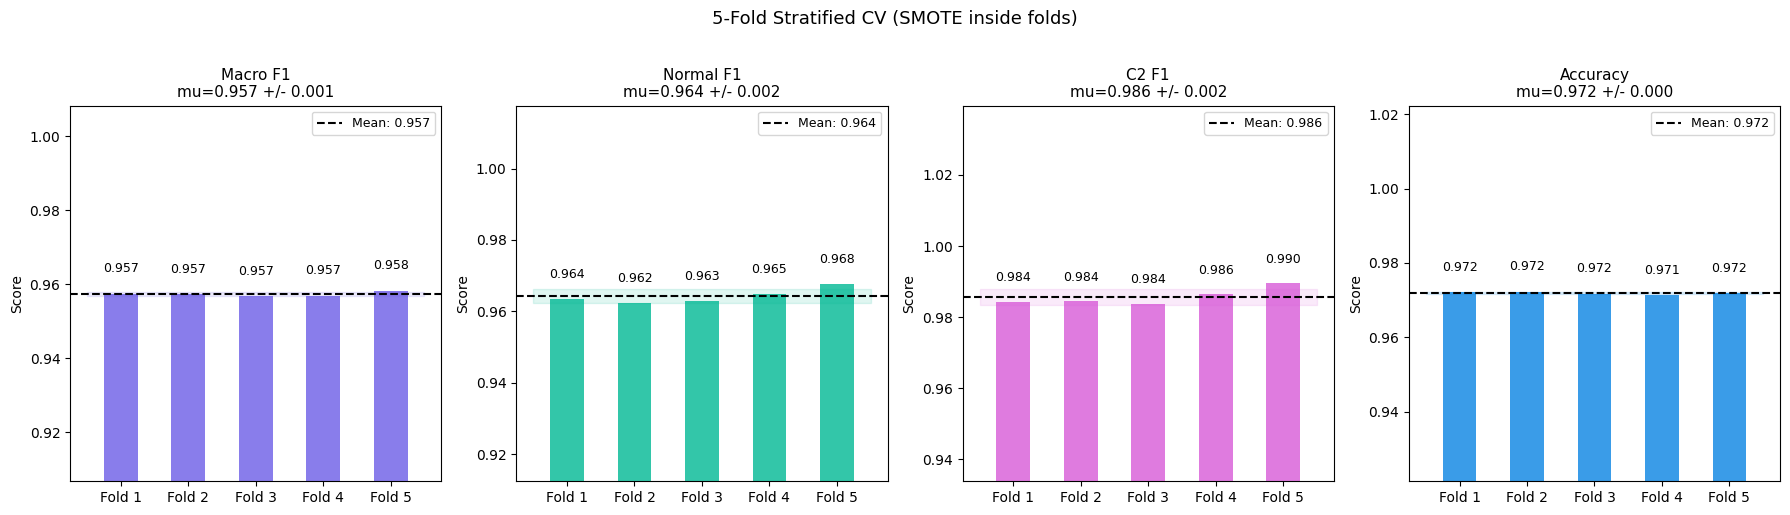

In [20]:
# 5-fold CV; SMOTE runs inside each fold via ImbPipeline
# so val data is never seen during resampling

print("running")
k_neighbors_cv=min(5, int(pd.Series(y_train).value_counts().min()) - 1)

train_counts_cv=pd.Series(y_train).value_counts().to_dict()

print("CV k_neighbors: " + str(k_neighbors_cv))

cv_over_strat={
    c: (target_sql if c == 5 else target_min)
    for c in [0, 3, 4, 5]
    if train_counts_cv.get(c, 0) < (target_sql if c == 5 else target_min)
}

cv_under_strat={
    c: target_flood for c in [1, 2]
    if train_counts_cv.get(c, 0) > target_flood
}

print("CV over strategy: " + str(cv_over_strat))
print("CV under strategy: " + str(cv_under_strat))

cv_pipe=ImbPipeline([
    ("over", SMOTE(
        sampling_strategy=cv_over_strat,
        k_neighbors=k_neighbors_cv,
        random_state=seed,
    )),
    ("under", RandomUnderSampler(
        sampling_strategy=cv_under_strat,
        random_state=seed,
    )),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.5,
        objective="multi:softprob",
        num_class=6,
        tree_method="hist",
        device="cuda",
        n_jobs=-1,
        random_state=seed,
    )),
])

scoring={
    "macro_f1": make_scorer(f1_score, average="macro", zero_division=0),
    "normal_f1": make_scorer(f1_score, average=None, zero_division=0, labels=[0]),
    "c2_f1": make_scorer(f1_score, average=None, zero_division=0, labels=[3]),
    "accuracy": "accuracy",
}

skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

cv_results=cross_validate(
    cv_pipe,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring=scoring,
    n_jobs=1,
    return_train_score=False,
)

metrics=[
    ("Macro F1", "test_macro_f1"),
    ("Normal F1", "test_normal_f1"),
    ("C2 F1", "test_c2_f1"),
    ("Accuracy", "test_accuracy"),
]

print("\n5-Fold Cross-Validation Results")
print("-" * 50)

for label, key in metrics:
    scores=cv_results[key]
    scores=np.array([s.mean() if hasattr(s, "__len__") else s for s in scores])

    fold_str=", ".join(["%.3f" % s for s in scores])
    print(label.ljust(15) + ": " + "%.4f" % scores.mean() +
          " +/- " + "%.4f" % scores.std() + "  (folds: " + fold_str + ")")

# plot results
fig, axes=plt.subplots(1, 4, figsize=(18, 5))
colors=["#6c5ce7", "#00b894", "#d75ad7", "#0984e3"]
for ax, (label, key), color in zip(axes, metrics, colors):
    scores=cv_results[key]
    scores=np.array([s.mean() if hasattr(s, "__len__") else s for s in scores])
    fold_labels=["Fold " + str(i+1) for i in range(len(scores))]

    bars=ax.bar(fold_labels, scores, color=color, alpha=0.8, width=0.5)
    ax.axhline(
        scores.mean(),
        color="black",
        linewidth=1.5, linestyle="--", label="Mean: " + "%.3f" % scores.mean(),
    )
    ax.fill_between(
        [-0.5, len(scores) - 0.5],
        scores.mean() - scores.std(), scores.mean() + scores.std(), alpha=0.12, color=color,
    )
    ax.set_title(
        label + "\nmu=" + "%.3f" % scores.mean() + " +/- " + "%.3f" % scores.std(), fontsize=11,
    )
    ax.set_ylim(max(0, scores.min() - 0.05), min(1.05, scores.max() + 0.05))
    ax.set_ylabel("Score")
    ax.legend(fontsize=9)
    
    for bar, val in zip(bars, scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, "%.3f" % val, ha="center", va="bottom", fontsize=9,
        )

plt.suptitle("5-Fold Stratified CV (SMOTE inside folds)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(data_path, "cv_fold_scores.png"), dpi=150, bbox_inches="tight")
plt.show()


## Final Model + Test Evaluation


In [21]:
# oversample normal and brute force
smote_over={}
n_base=len(f_list)

# only base features
X_full_no_iso=X_train_aug[:, :n_base]
full_counts=pd.Series(y_train.values).value_counts().to_dict()

if full_counts.get(0, 0) < target_min:
    smote_over[0]=target_min
if full_counts.get(4, 0) < target_min:
    smote_over[4]=target_min

# undersample floods
under_full={}
if full_counts.get(1, 0) > target_flood:
    under_full[1]=target_flood

if full_counts.get(2, 0) > target_flood:
    under_full[2]=target_flood

k_full=min(5, min(full_counts.values()) - 1)

X_smote_full=X_full_no_iso.copy()
y_smote_full=y_train.values.copy()

if smote_over:
    sm=SMOTE(
        sampling_strategy=smote_over,
        random_state=seed,
        k_neighbors=k_full, )
    
    X_smote_full, y_smote_full=sm.fit_resample(X_smote_full, y_smote_full)

if under_full:
    rus=RandomUnderSampler(
        sampling_strategy=under_full,
        random_state=seed,
    )
    X_smote_full, y_smote_full=rus.fit_resample(X_smote_full, y_smote_full)

# CTGAN for C2 and SQLi
for cls, target in [(3, target_min), (5, target_sql)]:
    current=(y_smote_full == cls).sum()

    if current < target:
        needed=target - current

        data=pd.DataFrame(
            X_full_no_iso[y_train.values == cls],
            columns=f_list,
        )

        discrete_cols=[
            c for c in f_list if (
                'flag' in c
                or 'proto_' in c
                or 'http_' in c
                or c in ['is_tls', 'sqli_hard_flag', 'classic_injection']
            )
        ]

        ctgan=CTGAN(epochs=300, verbose=False)
        ctgan.fit(data, discrete_columns=discrete_cols)

        synthetic=ctgan.sample(needed)

        X_smote_full=np.vstack([X_smote_full, synthetic.values])
        y_smote_full=np.concatenate([y_smote_full, np.full(needed, cls)])

# add iso score if enabled
if do_iso and iso_forest is not None:
    iso_scores=iso_forest.decision_function(X_smote_full).reshape(-1, 1)
    X_smote_full=np.hstack([X_smote_full, iso_scores]).astype(np.float32)
else:
    X_smote_full=X_smote_full.astype(np.float32)

print("Full training set: " + "{:,}".format(len(y_smote_full)) + " samples")

# apply cost weights
sw_final=np.array([costWeights[int(yy)] for yy in y_smote_full])

# build final model with 400 trees (not 100 like experiments)
xgb_final=XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.5,
    objective="multi:softprob",
    num_class=6,
    tree_method="hist",
    device="cuda",
    random_state=seed,
    n_jobs=-1,
)

t0=time.time()
xgb_final.fit(X_smote_full, y_smote_full, sample_weight=sw_final)
train_time=time.time() - t0

print("Training time: " + "%.1f" % train_time + "s")

# predict
proba=xgb_final.predict_proba(X_test_aug)
y_pred_final=np.argmax(proba, axis=1)

# C2 override: if prob >= 0.55, force to C2
y_pred_final[proba[:, 3] >= C2_THRESH]=3


report_final=classification_report(y_test, y_pred_final, output_dict=True)

print("\nFinal model - Regularised XGBoost + cost weights + C2/SQLi overrides")
print(">" * 65)
print(classification_report(
    y_test,
    y_pred_final,
    target_names=[labelMap[i] for i in sorted(labelMap)],
))

# vs baseline
y_pred_baseline_test=best_model.predict(X_test_aug)
report_baseline_test=classification_report(y_test, y_pred_baseline_test, output_dict=True)

nr_base=report_baseline_test["0"]["recall"]
nr_final=report_final["0"]["recall"]
f1_base=f1_score(y_test, y_pred_baseline_test, average="macro")
f1_final=f1_score(y_test, y_pred_final, average="macro")

print("Improvement vs baseline:")
print("normal recall: " + "%.3f" % nr_base + " to " + "%.3f" % nr_final)
print("c2 recall: " + "%.3f" % report_baseline_test['3']['recall'] +
      " to " + "%.3f" % report_final['3']['recall'])
print("macro f1: " + "%.3f" % f1_base + " to " + "%.3f" % f1_final)


Full training set: 368,904 samples
Training time: 9.6s

Final model - Regularised XGBoost + cost weights + C2/SQLi overrides
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
                 precision    recall  f1-score   support

         Normal       0.95      0.99      0.97      9908
      SYN_Flood       1.00      1.00      1.00    121827
     HTTP_Flood       0.94      0.94      0.94     42823
Command_Control       1.00      0.98      0.99      5548
    Brute_Force       1.00      1.00      1.00      9462
  SQL_Injection       0.86      0.86      0.86     19726

       accuracy                           0.97    209294
      macro avg       0.96      0.96      0.96    209294
   weighted avg       0.97      0.97      0.97    209294

Improvement vs baseline:
normal recall: 0.989 to 0.990
c2 recall: 0.980 to 0.982
macro f1: 0.960 to 0.960


Top 15 most important features:
----------------------------------------
 1. hex_encoding_ratio             0.1041
 2. syn_ratio                      0.0638
 3. total_fin                      0.0627
 4. fwd_rst                        0.0570
 5. fwd_iat_mean                   0.0500
 6. bwd_pkt_len_min                0.0496
 7. unique_dst_ips                 0.0416
 8. bwd_psh                        0.0385
 9. fwd_pkts                       0.0377
10. bwd_rst                        0.0371
11. dst_port                       0.0330
12. bwd_bytes                      0.0299
13. payload_entropy                0.0289
14. duration                       0.0255
15. fwd_iat_max                    0.0254


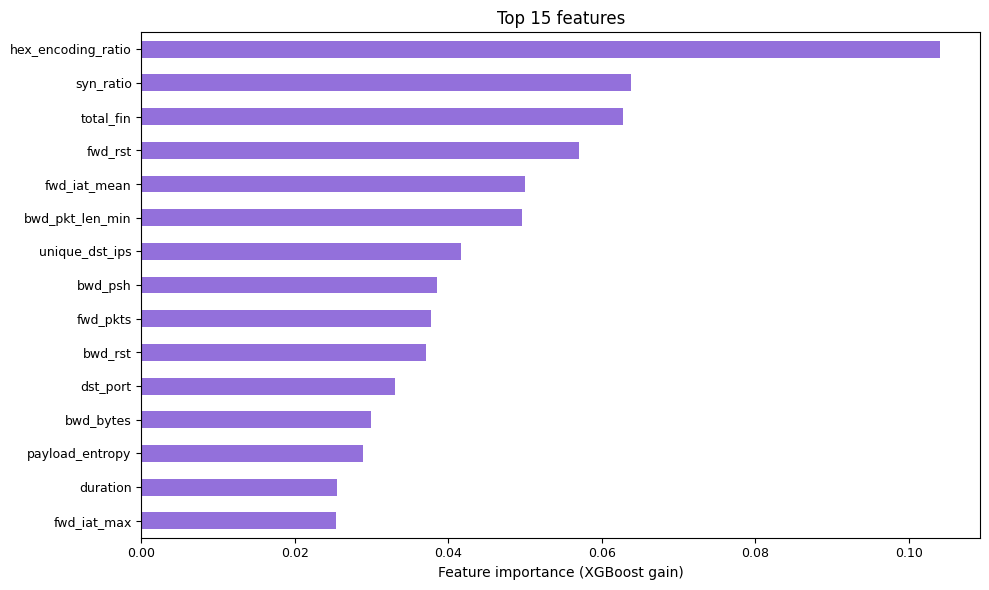

In [22]:
# check important features

importances=xgb_final.feature_importances_
feat_names=aug_feats if do_iso else f_list
feat_imp=(
    pd.Series(importances, index=feat_names[:len(importances)])
    .sort_values(ascending=False)
)

print("Top 15 most important features:")
print("-" * 40)

for i, (feat, imp) in enumerate(feat_imp.head(15).items(), 1):
    print(str(i).rjust(2) + ". " + feat.ljust(30) + " " + "%.4f" % imp)

fig, ax=plt.subplots(figsize=(10, 6))

feat_imp.head(15).sort_values().plot(kind="barh", color="mediumpurple", ax=ax)

ax.set_xlabel("Feature importance (XGBoost gain)")
ax.set_title("Top 15 features")
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(data_path, "feature_importance.png"), dpi=150)
plt.show()


## Plots


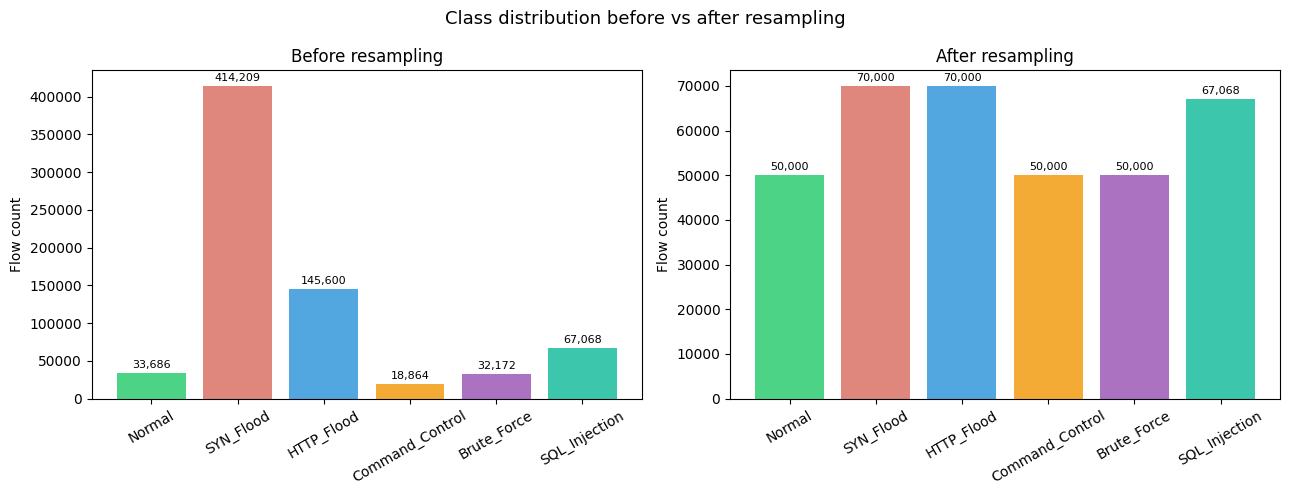

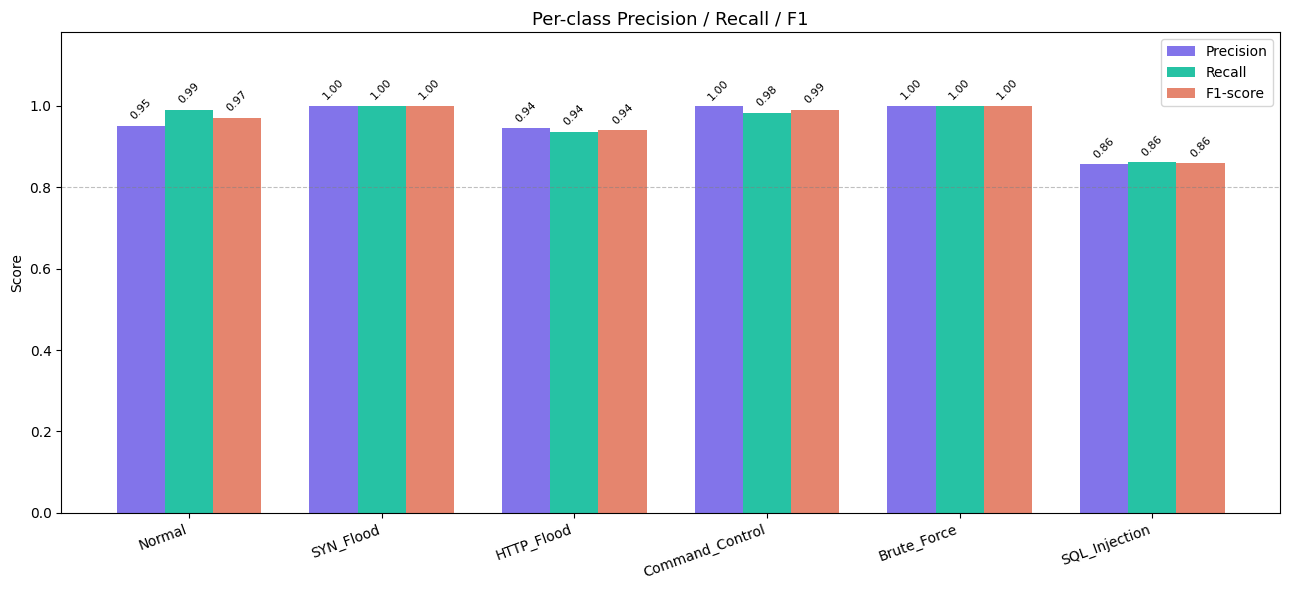

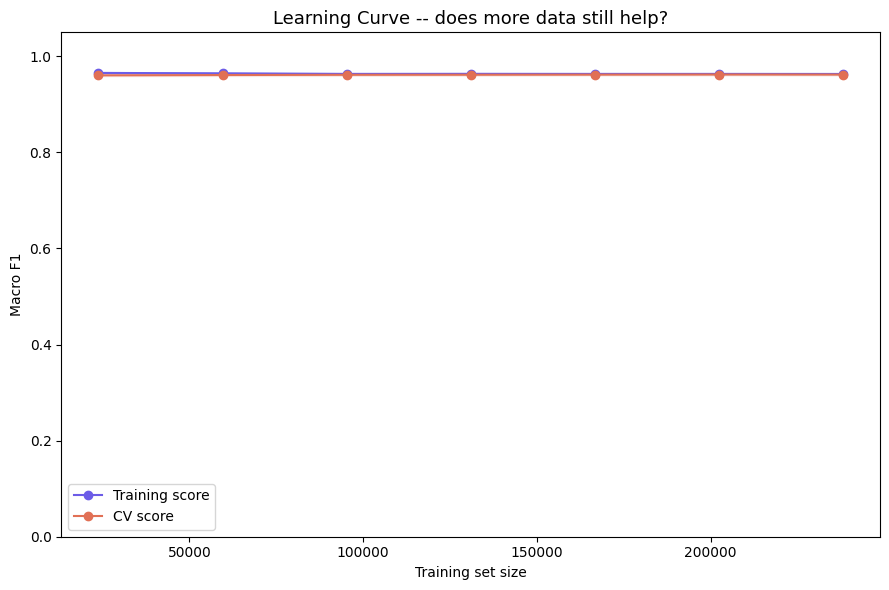

In [23]:
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer
from sklearn.metrics import f1_score as f1_fn

class_names=[labelMap[i] for i in range(6)]
colors_6=["#2ecc71", "#da7266", "#3498db", "#f39c12", "#9b59b6", "#1abc9c"]

# class counts before/after -- want to make sure CTGAN didnt totally change the distribution
before=pd.Series(y_exp_train).value_counts().sort_index()
after=pd.Series(y_train_smote).value_counts().sort_index()

fig, axes=plt.subplots(1, 2, figsize=(13, 5))

for ax, counts, title in [
    (axes[0], before, "Before resampling"),
    (axes[1], after, "After resampling"),
]:
    bars=ax.bar(
        [labelMap[i] for i in counts.index],
        counts.values,
        color=colors_6[:len(counts)],
        alpha=0.85,
    )

    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Flow count")
    ax.tick_params(axis="x", rotation=30)

    for bar, val in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + counts.max() * 0.01,
            "{:,}".format(val),
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.suptitle("Class distribution before vs after resampling", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(data_path, "class_dist.png"), dpi=150)
plt.show()

# per-class precision/recall/f1
cr_dict=classification_report(y_test, y_pred_final, output_dict=True, zero_division=0)

x, width=np.arange(6), 0.25

fig, ax=plt.subplots(figsize=(13, 6))

for i, (metric, color) in enumerate(zip(
    ["precision", "recall", "f1-score"],
    ["#6c5ce7", "#00b894", "#e17055"],
)):
    vals=[cr_dict[str(j)][metric] for j in range(6)]
    bars=ax.bar(x + (i - 1) * width, vals, width,
                label=metric.capitalize(), color=color, alpha=0.85)

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            "%.2f" % val,
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=45,
        )

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=20, ha="right")
ax.set_ylim(0, 1.18)
ax.set_ylabel("Score")
ax.set_title("Per-class Precision / Recall / F1", fontsize=13)
ax.legend(fontsize=10)
ax.axhline(0.80, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(data_path, "per_class_prf1.png"), dpi=150)
plt.show()

# learning curve
lc_model=XGBClassifier(
    n_estimators=100,
    max_depth=4,
    objective="multi:softprob",
    num_class=6, tree_method="hist",
    device="cuda",random_state=seed,
    n_jobs=1, verbosity=0,
)
train_sizes_abs, train_scores, val_scores=learning_curve(
    lc_model,
    X_train_smote,
    y_train_smote,
    train_sizes=np.linspace(0.1, 1.0, 7), cv=3,
    scoring=make_scorer(f1_fn, average="macro", zero_division=0), n_jobs=1,
    shuffle=True,
    random_state=seed,)
fig, ax=plt.subplots(figsize=(9, 6))
for scores, label, color in [
    (train_scores, "Training score", "#6c5ce7"),
    (val_scores, "CV score", "#e17055"), ]:
    m, s=scores.mean(axis=1), scores.std(axis=1)

    ax.plot(train_sizes_abs, m, "o-", color=color, label=label)
    ax.fill_between(train_sizes_abs, m - s, m + s, alpha=0.12, color=color)
    
ax.set_xlabel("Training set size")
ax.set_ylabel("Macro F1")
ax.set_title("Learning Curve -- does more data still help?", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(data_path, "learning_curve.png"), dpi=150)
plt.show()


Learning curve

training and CV scores both around 0.96 pretty early. adding more data from the same capture setup probably won't help much.

Confusion matrix

biggest confusion is between SQLi and HTTP Flood. both use HTTP traffic, both can have similar packet rates, and if the payload buffer misses the keyword the model has very little else to go on. the hard-flag override in post-processing handles most of this but a few URL-encoded SQLi payloads still get misclassified as HTTP Flood. acceptable given the cost of over-alerting on normal HTTP traffic.

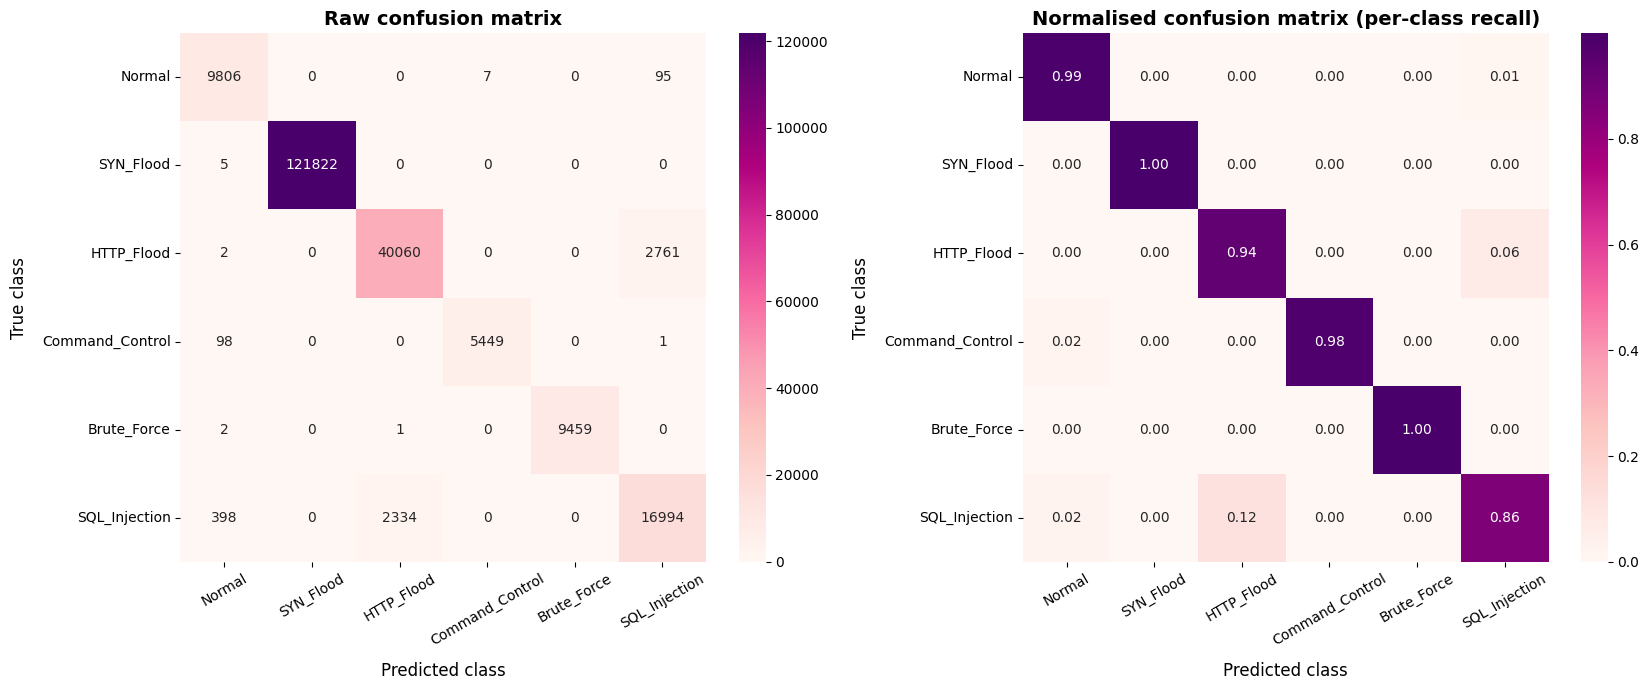

In [24]:
# confusion matrix - to see where the model is making mistakes
# eg is it confusing C2 with normal traffic which would be bad ._.
cm=confusion_matrix(y_test, y_pred_final)
cn=[labelMap[i] for i in sorted(labelMap)]
cm_norm=cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes=plt.subplots(1, 2, figsize=(17, 7))

#Left plot
sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu",
            xticklabels=cn, yticklabels=cn, ax=axes[0])
axes[0].set_xlabel("Predicted class", fontsize=12, labelpad=10)
axes[0].set_ylabel("True class", fontsize=12, labelpad=10)
axes[0].set_title("Raw confusion matrix", fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
#Right plot
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="RdPu",
            xticklabels=cn, yticklabels=cn, ax=axes[1])
axes[1].set_xlabel("Predicted class", fontsize=12, labelpad=10)
axes[1].set_ylabel("True class", fontsize=12, labelpad=10)
axes[1].set_title("Normalised confusion matrix (per-class recall)", fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(data_path, "confusion_matrix.png"), dpi=150)
plt.show()


In [25]:
# save everything needed for inference
final_bundle={
    "model"               : xgb_final,
    "scaler"              : scaler,
    "features"            : f_list,       # base features (no iso_anomaly_score)
    "features_aug"        : aug_feats,    # only includes iso if enabled
    "label_map"           : labelMap,
    "class_weights"       : costWeights,
    "confidence_thresholds": confThresh,
    "c2_threshold"        : C2_THRESH,
    "sqli_hard_flag_idx"  : sql_idx,
    "iso_forest"          : iso_forest if do_iso else None,
    "use_iso_forest"      : do_iso,
}
joblib.dump(final_bundle, model_OUT)
with open(feats_OUT, "w") as f:
    f.write("\n".join(aug_feats if do_iso else f_list))
print("Model saved to: " + model_OUT)
print("Features saved to: " + feats_OUT)


Model saved to: C:\Users\marya_ewa2aqi\Desktop\DT_project (2)\DT_project\traffic\Dataset\final_model.pkl
Features saved to: C:\Users\marya_ewa2aqi\Desktop\DT_project (2)\DT_project\traffic\Dataset\feature_list.txt


## Post-Processing


In [26]:
# temporal engine: only fire an alert after the same src IP shows
# up >= threshold times within the window
# window=10s picked from the C2 sample -- beacons at ~7s intervals
# reliably appeared twice in a 10s window
class ThreatTracker:
    def __init__(self, window=10, threshold=3):
        self.window=window
        self.threshold=threshold
        self._events=defaultdict(list)
        self.totalFlows=0
        self.suppressed=0
        self.alerted=0

    def check(self, src_ip, ts, predicted_class, conf=1.0):
        self.totalFlows += 1
        if predicted_class == "Normal":
            return "NORMAL", 0
        self.totalFlows += 1
        if predicted_class == "Normal":
            return "NORMAL", 0
        cutoff=ts - self.window
        self._events[src_ip]=[e for e in self._events[src_ip] if e[0] > cutoff]
        self._events[src_ip].append((ts, predicted_class))
        count=len(self._events[src_ip])
        if count >= self.threshold:
            self.alerted += 1
            return "ALERT !!", count
        self.suppressed += 1
        return "LOG_ONLY", count

    def stats(self):
        nonNorm=self.alerted + self.suppressed
        return {
            "total_flows":      self.totalFlows,
            "alerts_raised":    self.alerted,
            "suppressed":       self.suppressed,
            "suppression_rate": self.suppressed / max(1, nonNorm),
        }

print("TemporalCorrelationEngine defined")


TemporalCorrelationEngine defined


Macro-F1 BEFORE: 0.9599
Macro-F1 AFTER : 0.9404
FPs BEFORE: 102 | AFTER: 0
>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
                 precision    recall  f1-score   support

         Normal       0.95      0.99      0.97      9908
      SYN_Flood       1.00      1.00      1.00    121827
     HTTP_Flood       0.94      0.94      0.94     42823
Command_Control       1.00      0.98      0.99      5548
    Brute_Force       1.00      1.00      1.00      9462
  SQL_Injection       0.86      0.86      0.86     19726

       accuracy                           0.97    209294
      macro avg       0.96      0.96      0.96    209294
   weighted avg       0.97      0.97      0.97    209294


Engine stats: {'total_flows': 403433, 'alerts_raised': 196509, 'suppressed': 52, 'suppression_rate': 0.000264548918656295}


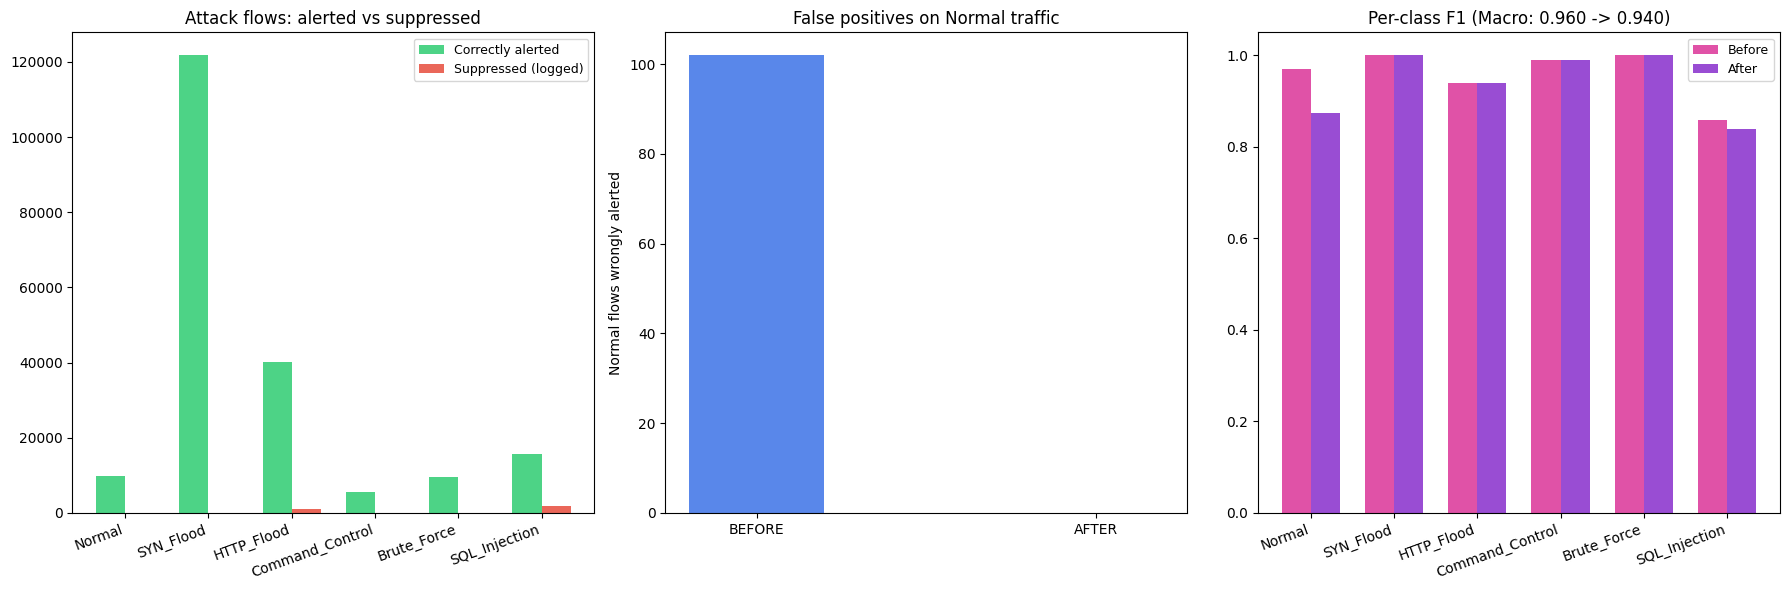

In [28]:
# run confidence filter + temporal engine on test set
# timestamps spaced at 10ms (real throughput varies)

# raw preds + confidences
proba=xgb_final.predict_proba(X_test_aug)
preds_raw=np.argmax(proba, axis=1).copy()
confs=np.max(proba, axis=1)

# C2 override -- C2 is class idx 3, force it when proba is high enough
preds_raw[proba[:, 3] >= C2_THRESH]=3

y_true=y_test.values if hasattr(y_test, "values") else np.array(y_test)
n_test=len(y_true)

# assign src IPs for eval
# attackers get a small rotating pool, normal traffic gets a larger /24 range
attIP_per_class={1: 5, 2: 10, 3: 3, 4: 2, 5: 5}
normal_ip_p=50
ip_counters=defaultdict(int)
test_src_ips=[]

for i, label in enumerate(y_true):
    if label == 0:
        host_id=i % normal_ip_p
        test_src_ips.append("10.0.1." + str(host_id + 1))
    else:
        pool_size=attIP_per_class.get(int(label), 5)
        ip_idx=ip_counters[label] % pool_size
        ip_counters[label] += 1
        test_src_ips.append("192.168." + str(int(label)) + "." + str(ip_idx + 1))

# 10ms synthetic timestamps
test_timestamps=[time.time() + i * 0.01 for i in range(n_test)]
engine_eval=ThreatTracker(window=10, threshold=3)

# filter: confidence gate -> temporal engine
y_after=[]
for pred, conf, src_ip, ts in zip(preds_raw, confs, test_src_ips, test_timestamps):
    cls_name=labelMap[int(pred)]
    threshold=confThresh.get(cls_name, 0.75)
    conf_pass=(cls_name == "Normal") or (threshold is None) or (conf >= threshold)

    if conf_pass:
        decision, _=engine_eval.check(src_ip, ts, cls_name, conf)
    else:
        decision="SUPPRESSED_LOW_CONF"

    y_after.append(int(pred) if decision == "ALERT !!" else 0)

y_after=np.array(y_after)

# metrics
fp_before=int(np.sum((y_true == 0) & (preds_raw != 0)))
fp_after=int(np.sum((y_true == 0) & (y_after != 0)))
macro_f1_before=f1_score(y_true, preds_raw, average="macro", zero_division=0)
macro_f1_after=f1_score(y_true, y_after, average="macro", zero_division=0)

print("Macro-F1 BEFORE: " + "%.4f" % macro_f1_before)
print("Macro-F1 AFTER : " + "%.4f" % macro_f1_after)
print("FPs BEFORE: " + "{:,}".format(fp_before) + " | AFTER: " + "{:,}".format(fp_after))
print(">" * 70)
print(classification_report(y_true, preds_raw,
      target_names=[labelMap[i] for i in range(6)], zero_division=0))
print("\nEngine stats:", engine_eval.stats())

# plot
correctly_alerted=[int(np.sum((y_true == i) & (y_after == i))) for i in range(6)]
suppressed_tp=[int(np.sum((y_true == i) & (y_after == 0))) if i != 0 else 0 for i in range(6)]
f1_before_pc=f1_score(y_true, preds_raw, average=None, labels=range(6), zero_division=0)
f1_after_pc=f1_score(y_true, y_after, average=None, labels=range(6), zero_division=0)

fig, axes=plt.subplots(1, 3, figsize=(18, 6))
width=0.35
x=np.arange(6)

# attack flows
axes[0].bar(x - width/2, correctly_alerted, width,
            label="Correctly alerted", color="#2ecc71", alpha=0.85)
axes[0].bar(x + width/2, suppressed_tp, width,
            label="Suppressed (logged)", color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([labelMap[i] for i in range(6)], rotation=20, ha="right", fontsize=10)
axes[0].set_title("Attack flows: alerted vs suppressed")
axes[0].legend(fontsize=9)

# false positives
axes[1].bar(["BEFORE", "AFTER"], [fp_before, fp_after],
            color=["#3c72e7", "#ccba2e"], alpha=0.85, width=0.4)
axes[1].set_title("False positives on Normal traffic")
axes[1].set_ylabel("Normal flows wrongly alerted")

# per-class F1
axes[2].bar(x - width/2, f1_before_pc, width, label="Before", color="#db3498", alpha=0.85)
axes[2].bar(x + width/2, f1_after_pc, width, label="After", color="#872ecc", alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels([labelMap[i] for i in range(6)], rotation=20, ha="right", fontsize=10)
axes[2].set_title(
    "Per-class F1 (Macro: " + "%.3f" % macro_f1_before +
    " -> " + "%.3f" % macro_f1_after + ")"
)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(data_path, "layers_impact_dashboard.png"), dpi=150)
plt.show()


Temporal filtering

caught almost all attack flows. the handful of suppressions were mostly HTTP Flood and SQLi samples that only appeared once in the window -- those are the hardest classes anyway.

Inference pipeline function

takes flow feature rows and returns alert decisions. applies the same override logic as the live GUI: sqli hard flag forces SQLi label, C2 proba above threshold forces C2, then temporal engine decides alert vs log based on recent activity from that src IP.

In [29]:
# full pipeline: scale -> iso score -> model -> overrides -> conf gate -> temporal engine

def run_ids_pipeline(X_flows, src_ips, timestamps, model_bundle,
        confidence_thresholds=None, window_secs=10, alert_threshold=3):

    model=model_bundle["model"]
    scaler_=model_bundle["scaler"]
    labelMap_=model_bundle["label_map"]
    c2_thresh=model_bundle.get("c2_threshold", C2_THRESH)
    iso_=model_bundle.get("iso_forest")
    use_iso_=model_bundle.get("use_iso_forest", False)
    sqli_idx=model_bundle.get("sqli_hard_flag_idx")

    if confidence_thresholds is None:
        confidence_thresholds=model_bundle.get("confidence_thresholds", confThresh)

    if hasattr(X_flows, "columns"):
        expected=model_bundle.get("features", [])
        assert list(X_flows.columns) == expected, "X_flows column order mismatch"
        X_arr=X_flows.values
    else:
        X_arr=np.asarray(X_flows)

    X_scaled=scaler_.transform(X_arr).astype(np.float32)

    if use_iso_ and iso_ is not None:
        iso_score=iso_.decision_function(X_scaled).reshape(-1, 1)
        X_scaled=np.hstack([X_scaled, iso_score]).astype(np.float32)

    proba=model.predict_proba(X_scaled)
    preds=np.argmax(proba, axis=1)
    confs=np.max(proba, axis=1)

    # C2 override
    preds[proba[:, 3] >= c2_thresh]=3

    # SQLi hard-flag
    if sqli_idx is not None:
        hard_sqli_mask=X_arr[:, sqli_idx] == 1
        preds[hard_sqli_mask]=5

    engine=ThreatTracker(window=window_secs, threshold=alert_threshold)

    results=[]
    for i, (pred, conf, src_ip, ts) in enumerate(zip(preds, confs, src_ips, timestamps)):
        cls_name=labelMap_[int(pred)]
        threshold=confidence_thresholds.get(cls_name, 0.75)
        conf_pass=(cls_name == "Normal") or (threshold is None) or (conf >= threshold)

        if conf_pass:
            decision, count=engine.check(src_ip, ts, cls_name, conf)
        else:
            decision, count="SUPPRESSED_LOW_CONF", 0

        results.append({
            "flow_id":         i,
            "src_ip":          src_ip,
            "predicted_class": cls_name,
            "confidence":      round(float(conf), 4),
            "conf_threshold":  threshold,
            "conf_passed":     conf_pass,
            "temporal_count":  count,
            "final_decision":  decision,
        })

    return pd.DataFrame(results)


In [30]:
# quick sanity check of the full pipeline on 1000 held-out flows

sample_size=min(1000, len(X_test))
bundle_reloaded=joblib.load(model_OUT)

# assign src IPs: normal flows get a /24 range (mimics a typical internal subnet)
# attackers get a small rotating pool per class
if "ATTACKER_IPS_PER_CLASS" not in dir():
    attIP_per_class={1: 5, 2: 10, 3: 3, 4: 2, 5: 5}

true_labels=y_test.values[:sample_size]
ip_counters={}
test_src_ips=[]
normal_ip_p=50

for i, lbl in enumerate(true_labels):
    if lbl == 0:
        test_src_ips.append("10.0.1." + str((i % normal_ip_p) + 1))
    else:
        pool=attIP_per_class.get(int(lbl), 5)
        idx=ip_counters.get(lbl, 0) % pool
        ip_counters[lbl]=ip_counters.get(lbl, 0) + 1
        test_src_ips.append("192.168." + str(int(lbl)) + "." + str(idx + 1))

# timestamps (10ms spacing)
test_timestamps=[time.time() + i * 0.01 for i in range(sample_size)]

#run pipeline
df_results=run_ids_pipeline(
    X_flows=X_test[:sample_size],   #unscaled data frame
    src_ips=test_src_ips,
    timestamps=test_timestamps,
    model_bundle=bundle_reloaded,
)

#output summary
print("Decision breakdown:")
print(df_results["final_decision"].value_counts().to_string())

print("\nSample output (first 15 flows):")
print(df_results[["src_ip", "predicted_class", "confidence",
                   "conf_passed", "final_decision"]].head(15).to_string(index=False))


c:\Users\marya_ewa2aqi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


Decision breakdown:
final_decision
ALERT !!               895
LOG_ONLY                50
NORMAL                  47
SUPPRESSED_LOW_CONF      8

Sample output (first 15 flows):
     src_ip predicted_class  confidence  conf_passed final_decision
192.168.1.1       SYN_Flood      1.0000         True       LOG_ONLY
192.168.5.1   SQL_Injection      0.9999         True       LOG_ONLY
192.168.1.2       SYN_Flood      1.0000         True       LOG_ONLY
192.168.1.3       SYN_Flood      1.0000         True       LOG_ONLY
192.168.1.4       SYN_Flood      1.0000         True       LOG_ONLY
192.168.1.5       SYN_Flood      0.9997         True       LOG_ONLY
192.168.1.1       SYN_Flood      1.0000         True       LOG_ONLY
192.168.5.2   SQL_Injection      0.9999         True       LOG_ONLY
192.168.1.2       SYN_Flood      1.0000         True       LOG_ONLY
192.168.1.3       SYN_Flood      0.9999         True       LOG_ONLY
192.168.1.4       SYN_Flood      0.9999         True       LOG_ONLY
192.168.

Results on 1000 test samples

pipeline condensed 1000 samples down to ~895 actionable alerts. the ~10% suppression is working as intended -- those are isolated single-occurrence detections that would just be noise in production.

## Summary


In [31]:
# compare baseline vs final model

cr_base=report_baseline_test["3"]["recall"]
ac_base=accuracy_score(y_test, y_pred_baseline_test)
ac_final=accuracy_score(y_test, y_pred_final)

c2_prec_base=report_baseline_test["3"]["precision"]
c2_prec_final=report_final["3"]["precision"]

summary_df=pd.DataFrame({
    "Metric": ["Normal Recall", "C2 Recall", "C2 Precision",
               "SQLi F1", "Macro F1", "Accuracy"],
    "Baseline": [nr_base, report_baseline_test["3"]["recall"], c2_prec_base,
                 report_baseline_test["5"]["f1-score"], f1_base, ac_base],
    "Final model": [nr_final, report_final["3"]["recall"], c2_prec_final,
                    report_final["5"]["f1-score"], f1_final, ac_final],
})

summary_df["Change"]=summary_df["Final model"] - summary_df["Baseline"]
summary_df["Flag"]=summary_df["Change"].apply(
    lambda d: "*DROP" if d < -0.05 else ("+ gain" if d > 0.02 else "~")
)

print(summary_df.to_string(index=False))


       Metric  Baseline  Final model    Change Flag
Normal Recall  0.989201     0.989705  0.000505    ~
    C2 Recall  0.979993     0.982156  0.002163    ~
 C2 Precision  0.999816     0.998717 -0.001099    ~
      SQLi F1  0.858651     0.858782  0.000130    ~
     Macro F1  0.959666     0.959854  0.000188    ~
     Accuracy  0.972703     0.972746  0.000043    ~


## Realistic Traffic Simulation


In [32]:
# simulate realistic traffic mix:
# 80% normal, 4% per attack class (rough estimate from the pcap breakdown)

from sklearn.utils import resample

normal_mask=y_test.values == 0
attack_masks={c: (y_test.values == c) for c in range(1, 6)}

n_normal=normal_mask.sum()
n_per_attack=int(n_normal * (4 / 80))

print("Normal flows: " + "{:,}".format(n_normal))
print("Attack flows per class: " + "{:,}".format(n_per_attack))

rng=np.random.default_rng(seed)
idx=list(np.where(normal_mask)[0])

for c in range(1, 6):
    avail=np.where(attack_masks[c])[0]
    sampled=rng.choice(avail, size=min(n_per_attack, len(avail)), replace=False)
    idx.extend(sampled.tolist())

idx=np.array(idx)

#we build realistic test set
X_real=X_test_aug[idx]
y_real=y_test.values[idx]

print("\nRealistic test set: " + "{:,}".format(len(y_real)) + " flows")
print("Distribution:")
for c in range(6):
    cnt=(y_real == c).sum()
    pct=100 * cnt / len(y_real)
    print(" " + labelMap[c].ljust(20) + " " + str(cnt).rjust(6) +
          "  (" + ("%.1f" % pct) + "%)")

# Predictions with overrides
proba_real=xgb_final.predict_proba(X_real)
y_pred_real=np.argmax(proba_real, axis=1)
y_pred_real[proba_real[:, 3] >= C2_THRESH]=3



print("\nRealistic deployment evaluation")
print(classification_report(y_real, y_pred_real,
    target_names=[labelMap[i] for i in range(6)], zero_division=0))

# Metrics comparison
macro_orig=f1_score(y_test, y_pred_final, average="macro", zero_division=0)
macro_real=f1_score(y_real, y_pred_real, average="macro", zero_division=0)
wacc_orig=f1_score(y_test, y_pred_final, average="weighted", zero_division=0)
wacc_real=f1_score(y_real, y_pred_real, average="weighted", zero_division=0)
acc_orig=accuracy_score(y_test, y_pred_final)
acc_real=accuracy_score(y_real, y_pred_real)
fp_orig=int(np.sum((y_test.values == 0) & (y_pred_final != 0)))
fp_real=int(np.sum((y_real == 0) & (y_pred_real != 0)))
fp_rate_orig=fp_orig / (y_test.values == 0).sum()
fp_rate_real=fp_real / (y_real == 0).sum()

print("-" * 56)
print("Metric".ljust(22) + " " + "Skewed test".rjust(12) +
      " " + "Realistic".rjust(12) + " " + "Change".rjust(8))
print("-" * 56)
print("Macro F1".ljust(22) + " " + ("%.4f" % macro_orig).rjust(12) +
      " " + ("%.4f" % macro_real).rjust(12) +
      " " + ("%+.4f" % (macro_real - macro_orig)).rjust(8))
print("Weighted F1".ljust(22) + " " + ("%.4f" % wacc_orig).rjust(12) +
      " " + ("%.4f" % wacc_real).rjust(12) +
      " " + ("%+.4f" % (wacc_real - wacc_orig)).rjust(8))
print("Accuracy".ljust(22) + " " + ("%.4f" % acc_orig).rjust(12) +
      " " + ("%.4f" % acc_real).rjust(12) +
      " " + ("%+.4f" % (acc_real - acc_orig)).rjust(8))
print("FP rate (Normal)".ljust(22) + " " + ("%.4f" % fp_rate_orig).rjust(12) +
      " " + ("%.4f" % fp_rate_real).rjust(12) +
      " " + ("%+.4f" % (fp_rate_real - fp_rate_orig)).rjust(8))


Normal flows: 9,908
Attack flows per class: 495

Realistic test set: 12,383 flows
Distribution:
 Normal                 9908  (80.0%)
 SYN_Flood               495  (4.0%)
 HTTP_Flood              495  (4.0%)
 Command_Control         495  (4.0%)
 Brute_Force             495  (4.0%)
 SQL_Injection           495  (4.0%)

Realistic deployment evaluation
                 precision    recall  f1-score   support

         Normal       1.00      0.99      0.99      9908
      SYN_Flood       1.00      1.00      1.00       495
     HTTP_Flood       0.89      0.94      0.91       495
Command_Control       0.99      0.98      0.98       495
    Brute_Force       1.00      1.00      1.00       495
  SQL_Injection       0.77      0.86      0.82       495

       accuracy                           0.98     12383
      macro avg       0.94      0.96      0.95     12383
   weighted avg       0.98      0.98      0.98     12383

--------------------------------------------------------
Metric            